# 第二问：日前购电与实时储能执行

本 Notebook 可独立运行，内嵌从附件 1、2 重建的数据，无需第一问目录。

**先看第 2 节参数，再从上到下运行。** 比较七日均值基准、28 日历史情景模型和无储能对照，保留 1 月预热及 2—12 月的完整结果。

当前按“时刻 t 的功率代表前 10 分钟平均功率”计算，原模板时间列存在错位，提交前需确认。功率乘 1/6 转为 kWh；充电、放电效率各取 90%。

这是一份可复现的第二问完整工作版本。日前模型优化的是历史情景近似目标，实时执行规则为启发式，不宣称未知未来下的全局最优。


## 1. 环境

在 VS Code 中选择 `cumcm2026` 内核。需要 numpy、pandas、scipy、matplotlib、ipykernel。完整项目的原始 Excel 重提取额外需要 openpyxl。

当前文件已保存真实运行输出。制作环境按顺序执行全部 Python 单元，未测试 Jupyter 内核协议。


In [1]:
from pathlib import Path
import json, io, gzip, base64, time
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import linprog, milp, Bounds, LinearConstraint
from scipy.sparse import coo_matrix, hstack, vstack, csr_matrix
try:
    from IPython.display import display, Image
except ImportError:
    if 'display' not in globals():
        display = print
    if 'Image' not in globals():
        Image = lambda filename: Path(filename)
pd.set_option('display.max_columns', 16)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('Python numerical stack:', np.__version__, pd.__version__, scipy.__version__)


Python numerical stack: 2.4.6 3.0.5 1.17.1


## 2. 参数与关键假设

- 1 月 1 日初始储电量为 6000 kWh，当天无历史数据：电池待机，光伏供电，不足应急补购。
- 1 月 2 日起使用已结束的历史天运行策略；1 月属于预热，不进入题面要求的 2—12 月费用汇总。
- 每天计划的末端目标为 6000 kWh。这是防止单日模型耗尽储能的策略假设，**不是第二题强制的日循环约束**。
- 实际末端状态不强制等于 6000，直接成为下一天的初始状态。
- 每个 10 分钟内允许根据当期负载和光伏完成平衡，忽略监测、控制延迟。
- 历史窗口取 28 日，基准取 7 日，均事先固定，不根据 2—12 月回测费用选择。

窗口或电池参数修改后需重新运行后续单元；策略代号中的 7/28 是默认值，实际值以 cfg 为准。


In [2]:
DEFAULT = {'interval_minutes': 10, 'charge_efficiency': 0.9, 'discharge_efficiency': 0.9, 'storage_min_kwh': 1200.0, 'storage_max_kwh': 10800.0, 'initial_storage_kwh': 6000.0, 'planned_terminal_kwh': 6000.0, 'max_charge_power_kw': 5000.0, 'max_discharge_power_kw': 5000.0, 'emergency_multiplier': 5.0, 'scenario_days': 28, 'mean_days': 7, 'tolerance': 1e-06}
cfg = DEFAULT.copy()
REPORT_DATES = ['2025-03-20', '2025-06-21', '2025-09-23', '2025-12-21']
METHODS = ['mean7_battery', 'saa28_battery', 'saa28_no_battery']
PRIMARY = 'saa28_battery'
OUT = Path.cwd() / 'q2_notebook_results'
OUT.mkdir(exist_ok=True)
display(pd.DataFrame(list(cfg.items()),columns=['参数','数值']))


,参数,数值
0,interval_minutes,10.0000
1,charge_efficiency,0.9000
2,discharge_efficiency,0.9000
3,storage_min_kwh,"1,200.0000"
4,storage_max_kwh,"10,800.0000"
5,initial_storage_kwh,"6,000.0000"
6,planned_terminal_kwh,"6,000.0000"
7,max_charge_power_kw,"5,000.0000"
8,max_discharge_power_kw,"5,000.0000"
9,emergency_multiplier,5.0000


## 3. 输入数据与完整性

内嵌表只包含日期、时段、负载和光伏。电价单独来自附件 1。**第二问不读取附件 3、4，也不使用此前特征表中的历史实际电价列。**

内嵌数据展开后应有 365×144=52,560 行。保留原始数值，不填补、不削峰、不标准化；负净负载代表光伏富余，予以保留。


In [3]:
ACTUAL_B64 = '...'
PRICE_B64 = 'H4sIAAAAAAACAz1UW44QMAj85ywbU14tnGZjjIlGo5tVYzybHx7JKzhM3f2bQMsAA/z9/efb56/fH56eP757//jrx9svj0/vnx8//fwg+rDehEWJXZDiBLslCI5JXqCyCSrlDHBVKYJl0vdNi67rM1HGdndRe3mvN3rDxvBuIcr4vo8oCRzZ6GXwFL0UCS85/ITY5UBGdjlyi12OdDG/8cQuxUFxpIiFD5eiWuxSbIS7FEjKSBFm4pei0Y/XMpwUMIpfCsTz4UAm8A5HnlXiw9Gr8W442jdsw1EngfoiNHg4aiNKDEeBWGI4yj0khqNWwzYcp6FEDMfZAe9w7AJHHEaRqAd9o1uPRBOVSy6g1WhP6qCKlrRBWyV9QOBVDEDDMgdoHEmW0GhEsgRYpoCe1uQUgJgte/HVObKVSGEzeqtkOxEo9xTQhcZtFoCs9xDkspRNHfY22UXbQjjqUHbkUIczM6cv785/HYCoQ2CwDrXOBLpab5dDrRXanOHIXfhBHWZQD3XYKLuoQygQddhaUtRhm0uxjGXwsoyTIcVGLcx93UZhxuqMbdakil1f+MFW+dnSw7F3h7QSSQ/DMejVw3Ack9NUOqF+s1EF/t6cg0zpc3NXaVaRaHffaWqs1lo3UWzUohyKHuiiHrbHykoCHdR1S4mBSXFoZTHIVheLuf6pxlwn1gyWJWZHdSbLAqOiqrTidKgaoc3yz3RZ1byd+XJIBziN80RZimUfK78dwhprEeKOaBOdOR/r+hHWlAEmGzNaAfy68clI1Tkvh8oMuimXvt3HynFe2Ejl2vdcEbV+hVz8LsLp4jnTurv6tkDB3ffKgffATDBuf2gPvGOHlVTuP67qBOORMUfDvF+OrvIExEgW9xIjxbBXm79cXo3/13jLP6XL53TNBQAA'
actual = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(ACTUAL_B64))), float_precision='round_trip')
price_data = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(PRICE_B64))), float_precision='round_trip')


In [4]:
assert list(actual.columns) == ['date', 'slot', 'load_kw', 'pv_kw']
assert len(actual) == 52560 and not actual.duplicated(['date','slot']).any()
actual = actual.sort_values(['date','slot']).reset_index(drop=True)
dates = pd.DatetimeIndex(sorted(pd.to_datetime(actual.date.unique())))
assert dates.equals(pd.date_range('2025-01-01','2025-12-31'))
assert np.array_equal(actual.slot, np.tile(np.arange(1,145),365))
load = actual.load_kw.to_numpy().reshape(365,144)
pv = actual.pv_kw.to_numpy().reshape(365,144)
prices = price_data.price_yuan_per_kwh.to_numpy()
assert np.isfinite(load).all() and np.isfinite(pv).all() and (prices > 0).all()
print('天数 / 每天时段数:', load.shape, '；评价时段数:', 334*144)
display(actual.head())


天数 / 每天时段数: (365, 144) ；评价时段数: 48096


,date,slot,load_kw,pv_kw
0,2025-01-01,1,"3,529.7296",0.0000
1,2025-01-01,2,"3,609.5287",0.0000
2,2025-01-01,3,"3,726.5600",0.0000
3,2025-01-01,4,"3,510.6311",0.0000
4,2025-01-01,5,"3,502.5625",0.0000


## 4. 只用过去构造情景

第 d 天的第 s 个历史情景是此前最多 28 天中的一整天：

$$N^{(s)}_{d,t}=\frac{L_{d-s,t}-P_{d-s,t}}6.$$

不截断负值。七日均值基准先对过去最多 7 天同一时段取平均，作为唯一确定性情景。索引切片 `first:day_index` 明确排除当天及之后的数据。


In [5]:
def history_scenarios(load, pv, day_index, method, cfg):
    """Only complete days STRICTLY before the planning day are visible."""
    if day_index < 1:
        raise ValueError('Jan 1 has no historical data; use the explicit cold-start rule.')
    window = cfg['mean_days'] if method == 'mean7_battery' else cfg['scenario_days']
    first = max(0, day_index-window)
    scenario = (load[first:day_index]-pv[first:day_index])*cfg['interval_minutes']/60
    if method == 'mean7_battery':
        scenario = scenario.mean(axis=0, keepdims=True)
    return scenario, first


In [6]:
feb_index = int(np.flatnonzero(dates == pd.Timestamp('2025-02-01'))[0])
scenarios, first = history_scenarios(load, pv, feb_index, PRIMARY, cfg)
print('2 月 1 日情景形状:', scenarios.shape)
print('可见历史:', dates[first].date(), '至', dates[feb_index-1].date())
display(pd.DataFrame(scenarios[:3,:6], columns=[f'前{i+1}个时段' for i in range(6)]))


2 月 1 日情景形状: (28, 144)
可见历史: 2025-01-04 至 2025-01-31


,前1个时段,前2个时段,前3个时段,前4个时段,前5个时段,前6个时段
0,449.4657,459.6979,474.4667,443.8067,426.7046,456.2850
1,624.8523,622.4207,635.4433,633.6038,620.4684,616.5917
2,607.3945,611.2274,608.8933,609.8078,625.6360,638.5167


## 5. 日前随机规划近似模型

变量：计划普通购电 $g_t$、计划充放电 $c_t,d_t$、计划电量 $E_t$，以及固定该充放电计划时每个历史情景的应急量 $h_{s,t}$。

$$\min\sum_t p_tg_t+\frac1S\sum_s\sum_t5p_t h_{s,t}$$

$$g_t+h_{s,t}+d_t-c_t\ge N_{s,t},\qquad h_{s,t},g_t\ge0$$

$$E_{t+1}=E_t+0.9c_t-d_t/0.9,\qquad1200\le E_t\le10800$$

$$0\le c_t,d_t\le5000/6,\qquad c_td_t=0$$

初态取当天实测电量，计划末态目标取 6000。富余供给允许未使用。

先求 LP 松弛，检查充放电互斥；若冲突则用二进制模式变量求 MILP。若 LP 解满足互斥，它就是该日前情景模型的最优解。**情景中的应急量是优化辅助变量，不能当作当天已经发生的应急量。**

无储能对照逐时求解 $g+5\mathbb E[(N-g)^+]$，采用经验 80% 分位数。带储能模型通过时间耦合约束统一求解，不能直接逐时套分位数。


In [7]:
def plan_day(scenarios, prices, initial_kwh, cfg, battery=True):
    """min p*g + 5*p*mean(h); g+h_s+d-c >= net_s.

    All scenarios share the day-ahead battery schedule. h_s is a hypothetical
    emergency amount with that fixed battery schedule. Surplus may be unused.
    The actual controller below is a separately specified causal recourse rule.
    """
    a, p = np.asarray(scenarios, float), np.asarray(prices, float)
    if a.ndim != 2 or a.shape[1] != len(p) or not np.isfinite(a).all():
        raise ValueError('Invalid scenarios')
    if not (np.isfinite(p).all() and (p > 0).all()):
        raise ValueError('Prices must be positive')
    s, n = a.shape
    if not battery:
        # Any empirical 80%-quantile minimises g+5*mean((net-g)+).
        rank = max(0, int(np.ceil((1-1/cfg['emergency_multiplier'])*s))-1)
        g = np.maximum(np.sort(a, axis=0)[rank], 0)
        h = np.maximum(a-g, 0)
        return dict(grid=g, charge=np.zeros(n), discharge=np.zeros(n),
                    storage=np.full(n+1, initial_kwh), expected_emergency=h.mean(axis=0),
                    objective=float(p@g+cfg['emergency_multiplier']*(h@p).mean()),
                    solver='empirical quantile', plan_residual=0.)
    # x = [g(n), c(n), d(n), E(n+1), h(s*n)]
    h0, m = 4*n+1, 4*n+1+s*n
    obj = np.zeros(m); obj[:n] = p
    obj[h0:] = np.tile(cfg['emergency_multiplier']*p/s, s)
    ec, ed = cfg['charge_efficiency'], cfg['discharge_efficiency']
    mc = cfg['max_charge_power_kw']*cfg['interval_minutes']/60
    md = cfg['max_discharge_power_kw']*cfg['interval_minutes']/60
    lo, hi = cfg['storage_min_kwh'], cfg['storage_max_kwh']
    lower = np.zeros(m); upper = np.full(m, np.inf)
    upper[n:2*n], upper[2*n:3*n] = mc, md
    lower[3*n:4*n+1], upper[3*n:4*n+1] = lo, hi
    lower[3*n] = upper[3*n] = initial_kwh
    lower[4*n] = upper[4*n] = cfg['planned_terminal_kwh']
    t = np.arange(n)
    eq = coo_matrix((np.r_[-ec*np.ones(n), np.ones(n)/ed, -np.ones(n), np.ones(n)],
                     (np.tile(t,4), np.r_[n+t,2*n+t,3*n+t,3*n+t+1])), shape=(n,m)).tocsr()
    rows = np.arange(s*n); slots = np.tile(t,s)
    ub = coo_matrix((np.r_[-np.ones(s*n),np.ones(s*n),-np.ones(s*n),-np.ones(s*n)],
                     (np.tile(rows,4),np.r_[slots,n+slots,2*n+slots,h0+rows])),
                    shape=(s*n,m)).tocsr()
    b = -a.ravel()
    lp = linprog(obj, A_ub=ub, b_ub=b, A_eq=eq, b_eq=np.zeros(n),
                 bounds=np.column_stack([lower,upper]), method='highs')
    if not lp.success:
        raise RuntimeError(lp.message)
    x, solver = lp.x, 'LP'
    if ((x[n:2*n]>cfg['tolerance']) & (x[2*n:3*n]>cfg['tolerance'])).any():
        # A binary fallback prevents artificial simultaneous charge/discharge.
        mode = coo_matrix((np.r_[np.ones(n),-mc*np.ones(n),np.ones(n),md*np.ones(n)],
                    (np.r_[t,t,n+t,n+t],np.r_[n+t,m+t,2*n+t,m+t])),shape=(2*n,m+n)).tocsr()
        res = milp(np.r_[obj,np.zeros(n)], integrality=np.r_[np.zeros(m),np.ones(n)],
                   bounds=Bounds(np.r_[lower,np.zeros(n)],np.r_[upper,np.ones(n)]),
                   constraints=[LinearConstraint(hstack([eq,csr_matrix((n,n))]),0,0),
                     LinearConstraint(hstack([ub,csr_matrix((s*n,n))]),-np.inf,b),
                     LinearConstraint(mode,-np.inf,np.r_[np.zeros(n),md*np.ones(n)])],
                   options={'mip_rel_gap':1e-8})
        if not res.success:
            raise RuntimeError(res.message)
        x, solver = res.x[:m], 'MILP'
    if np.max(ub@x-b)>cfg['tolerance'] or np.max(abs(eq@x))>cfg['tolerance']:
        raise AssertionError('Planning constraints failed')
    return dict(grid=np.maximum(x[:n],0),charge=np.maximum(x[n:2*n],0),
                discharge=np.maximum(x[2*n:3*n],0),storage=x[3*n:4*n+1],
                expected_emergency=x[h0:].reshape(s,n).mean(axis=0),objective=float(obj@x),
                solver=solver,plan_residual=float(max(np.max(ub@x-b),np.max(abs(eq@x)),0)))


## 6. 实时执行与实际费用

普通购电 $g_t$ 全天固定。当前净余量为 $r_t=g_t+P_t-L_t$（均为 kWh）。

- $r_t\ge0$：在功率和容量上限内充电，其余记作未利用供电。
- $r_t<0$：在功率和最低电量限制内放电，其余缺口应急补购。

实际电量逐时更新，因此次日初态来自本日末态。这个控制器只读当前时段，不读取未来负载、光伏；计划储能轨迹用于日前购电优化，实际充放电根据当前余缺调整。

$$F_{\rm actual}=\sum_t p_tg_t+\sum_t5p_t h^{\rm actual}_t.$$

计划量没有使用也收费。未利用供电可能同时包含光伏和已购电，不能全部称为弃光。


In [8]:
def execute_day(grid, actual_load, actual_pv, initial_kwh, cfg, battery=True):
    """Online greedy rule; iteration t reads only actual interval t and E_t.

    Consume paid-for grid and PV; store surplus within limits; discharge for a
    deficit; buy any remaining shortage as emergency energy. No future lookup.
    Real-time balancing assumes observation/actuation inside the 10-min slot.
    """
    n = len(grid); e = np.empty(n+1); e[0] = initial_kwh
    c, d, h, w = [np.zeros(n) for _ in range(4)]
    ec, ed = cfg['charge_efficiency'], cfg['discharge_efficiency']
    mc = cfg['max_charge_power_kw']*cfg['interval_minutes']/60 if battery else 0
    md = cfg['max_discharge_power_kw']*cfg['interval_minutes']/60 if battery else 0
    for t in range(n):
        r = grid[t]+actual_pv[t]-actual_load[t]
        if r >= 0:
            c[t] = min(r,mc,max(0,(cfg['storage_max_kwh']-e[t])/ec))
            w[t] = r-c[t]
        else:
            d[t] = min(-r,md,max(0,(e[t]-cfg['storage_min_kwh'])*ed))
            h[t] = -r-d[t]
        e[t+1] = e[t]+ec*c[t]-d[t]/ed
    return dict(charge=c,discharge=d,emergency=h,unused=w,storage=e)


def run_strategy(load, pv, prices, dates, method, cfg=None, progress=True):
    cfg = dict(DEFAULT if cfg is None else cfg)
    if method not in METHODS: raise ValueError(method)
    if load.shape != pv.shape or load.shape[1] != 144 or len(prices)!=144:
        raise ValueError('Expect day x 144 inputs')
    state = cfg['initial_storage_kwh']; frames=[]; diary=[]
    battery = method != 'saa28_no_battery'
    for k, date in enumerate(dates):
        if k == 0:
            # Jan 1: no prior observation. No scheduled purchase, idle battery,
            # direct PV use, emergency fills deficit. January is warm-up only.
            plan = dict(grid=np.zeros(144),charge=np.zeros(144),discharge=np.zeros(144),
                        storage=np.full(145,state), expected_emergency=np.zeros(144),
                        objective=0.,solver='cold-start',plan_residual=0.)
            first = 0
        else:
            scenarios,first = history_scenarios(load,pv,k,method,cfg)
            plan = plan_day(scenarios,prices,state,cfg,battery)
        l,v = load[k]*cfg['interval_minutes']/60,pv[k]*cfg['interval_minutes']/60
        actual = execute_day(plan['grid'],l,v,state,cfg,battery and k>0)
        e = actual['storage']; state = float(e[-1])  # Never reset actual SOC.
        intervals = pd.date_range(date, periods=144, freq='10min')
        frame = pd.DataFrame(dict(date=str(pd.Timestamp(date).date()),slot=np.arange(1,145),
             interval_start=intervals,interval_end=intervals+pd.Timedelta(minutes=10),
             price_yuan_per_kwh=prices,load_kwh=l,pv_kwh=v,
             planned_grid_kwh=plan['grid'],planned_charge_kwh=plan['charge'],
             planned_discharge_kwh=plan['discharge'],planned_storage_start_kwh=plan['storage'][:-1],
             planned_storage_end_kwh=plan['storage'][1:],
             forecast_emergency_kwh=plan['expected_emergency'],charge_kwh=actual['charge'],
             discharge_kwh=actual['discharge'],emergency_kwh=actual['emergency'],
             unused_energy_kwh=actual['unused'],storage_start_kwh=e[:-1],storage_end_kwh=e[1:]))
        # Unused supply may contain bought energy. Do not label all of it curtailment.
        frame['planned_cost_yuan'] = prices*plan['grid']
        frame['emergency_cost_yuan'] = cfg['emergency_multiplier']*prices*actual['emergency']
        frame['total_cost_yuan'] = frame.planned_cost_yuan+frame.emergency_cost_yuan
        frame['evaluation'] = pd.Timestamp(date) >= pd.Timestamp('2025-02-01')
        frames.append(frame)
        diary.append(dict(date=str(pd.Timestamp(date).date()),solver=plan['solver'],
           history_first_date=None if k==0 else str(pd.Timestamp(dates[first]).date()),
           history_last_date=None if k==0 else str(pd.Timestamp(dates[k-1]).date()),
           history_days=0 if k==0 else k-first,objective_surrogate_yuan=plan['objective'],
           planning_constraint_residual=plan['plan_residual'],initial_actual_kwh=float(e[0]),
           terminal_actual_kwh=float(e[-1])))
        if progress and ((k+1)%60==0 or k==len(dates)-1):
            print(f'{method}: {k+1}/{len(dates)} days',flush=True)
    return pd.concat(frames,ignore_index=True),pd.DataFrame(diary)


def daily_summary(dispatch):
    sumcols=['planned_grid_kwh','emergency_kwh','planned_cost_yuan','emergency_cost_yuan',
             'total_cost_yuan','charge_kwh','discharge_kwh','unused_energy_kwh','load_kwh','pv_kwh']
    out=dispatch.groupby('date')[sumcols].sum()
    out['initial_storage_kwh']=dispatch.groupby('date').storage_start_kwh.first()
    out['terminal_storage_kwh']=dispatch.groupby('date').storage_end_kwh.last()
    out['emergency_slots']=dispatch.assign(event=dispatch.emergency_kwh>1e-6).groupby('date').event.sum()
    return out.reset_index()


def verify_physics(dispatch,cfg=None):
    cfg=DEFAULT if cfg is None else cfg; x=dispatch; tol=cfg['tolerance']
    def maximum(a):return float(np.max(np.abs(a)))
    residual=x.planned_grid_kwh+x.pv_kwh+x.discharge_kwh+x.emergency_kwh-x.load_kwh-x.charge_kwh-x.unused_energy_kwh
    evolution=x.storage_end_kwh-x.storage_start_kwh-cfg['charge_efficiency']*x.charge_kwh+x.discharge_kwh/cfg['discharge_efficiency']
    numerics={
      'energy_balance_kwh':maximum(residual), 'battery_update_kwh':maximum(evolution),
      'continuous_state_kwh':maximum(x.storage_start_kwh.to_numpy()[1:]-x.storage_end_kwh.to_numpy()[:-1]),
      'soc_lower_violation_kwh':max(0,float(cfg['storage_min_kwh']-x.storage_end_kwh.min())),
      'soc_upper_violation_kwh':max(0,float(x.storage_end_kwh.max()-cfg['storage_max_kwh'])),
      'charge_power_violation_kw':max(0,float(x.charge_kwh.max()*60/cfg['interval_minutes']-cfg['max_charge_power_kw'])),
      'discharge_power_violation_kw':max(0,float(x.discharge_kwh.max()*60/cfg['interval_minutes']-cfg['max_discharge_power_kw'])),
      'simultaneous_charge_discharge_slots':int(((x.charge_kwh>tol)&(x.discharge_kwh>tol)).sum()),
      'planned_cost_error_yuan':maximum(x.planned_cost_yuan-x.price_yuan_per_kwh*x.planned_grid_kwh),
      'emergency_cost_error_yuan':maximum(x.emergency_cost_yuan-cfg['emergency_multiplier']*x.price_yuan_per_kwh*x.emergency_kwh),
      'total_cost_error_yuan':maximum(x.total_cost_yuan-x.planned_cost_yuan-x.emergency_cost_yuan),
      'negative_flow_violation_kwh':max(0,-float(x[['planned_grid_kwh','charge_kwh','discharge_kwh','emergency_kwh','unused_energy_kwh']].min().min()))}
    checks=[dict(check=k,value=v,tolerance=tol,passed=v<=tol) for k,v in numerics.items()]
    checks += [dict(check='finite_numeric_values',value=None,tolerance=None,passed=bool(np.isfinite(x.select_dtypes('number')).all().all())),
               dict(check='continuous_time_axis',value=None,tolerance=None,passed=bool((pd.to_datetime(x.interval_start).iloc[1:].to_numpy()==pd.to_datetime(x.interval_end).iloc[:-1].to_numpy()).all()))]
    result=pd.DataFrame(checks)
    if not result.passed.all():raise AssertionError(result[~result.passed].to_string())
    return result


## 7. 先运行到 2 月 1 日，检查衔接

这里从 1 月 1 日开始真实递推，展示 2 月 1 日初态，不能直接把 6000 当作 2 月 1 日初态。


In [9]:
demo, demo_log = run_strategy(load[:32], pv[:32], prices, dates[:32], PRIMARY, cfg, progress=False)
display(daily_summary(demo).tail(2))
display(verify_physics(demo, cfg))


,date,planned_grid_kwh,emergency_kwh,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,charge_kwh,discharge_kwh,unused_energy_kwh,load_kwh,pv_kwh,initial_storage_kwh,terminal_storage_kwh,emergency_slots
30,2025-01-31,"95,708.1818",0.0000,"61,246.6904",0.0000,"61,246.6904","13,188.8241","6,807.6508","50,562.6855","80,009.9200","41,245.5969","6,494.1148","10,800.0000",0
31,2025-02-01,"90,923.8649",0.0000,"59,253.9968",0.0000,"59,253.9968","7,529.8610","6,099.1874","55,115.0153","76,305.2063","41,927.0304","10,800.0000","10,800.0000",0


,check,value,tolerance,passed
0,energy_balance_kwh,0.0000,0.0000,True
1,battery_update_kwh,0.0000,0.0000,True
2,continuous_state_kwh,0.0000,0.0000,True
3,soc_lower_violation_kwh,0.0000,0.0000,True
4,soc_upper_violation_kwh,0.0000,0.0000,True
5,charge_power_violation_kw,0.0000,0.0000,True
6,discharge_power_violation_kw,0.0000,0.0000,True
7,simultaneous_charge_discharge_slots,0.0000,0.0000,True
8,planned_cost_error_yuan,0.0000,0.0000,True
9,emergency_cost_error_yuan,0.0000,0.0000,True


## 8. 完整逐日回测

三个策略均从 1 月 1 日预热，仅用 2—12 月比较。默认参数在制作环境约几十秒完成，耗时依电脑而异。


In [10]:
started = time.perf_counter()
results = {name: run_strategy(load, pv, prices, dates, name, cfg) for name in METHODS}
print(f'运行耗时：{time.perf_counter()-started:.1f} 秒')


mean7_battery: 60/365 days
mean7_battery: 120/365 days
mean7_battery: 180/365 days
mean7_battery: 240/365 days
mean7_battery: 300/365 days
mean7_battery: 360/365 days
mean7_battery: 365/365 days
saa28_battery: 60/365 days
saa28_battery: 120/365 days
saa28_battery: 180/365 days
saa28_battery: 240/365 days
saa28_battery: 300/365 days
saa28_battery: 360/365 days
saa28_battery: 365/365 days
saa28_no_battery: 60/365 days
saa28_no_battery: 120/365 days
saa28_no_battery: 180/365 days
saa28_no_battery: 240/365 days
saa28_no_battery: 300/365 days
saa28_no_battery: 360/365 days
saa28_no_battery: 365/365 days
运行耗时：20.6 秒


In [11]:
def compare_strategies(results):
    rows=[]
    for name,(allx,_) in results.items():
        x=allx[allx.evaluation]; d=daily_summary(x)
        rows.append(dict(strategy=name,days=len(d),slots=len(x),
             **{k:float(x[k].sum()) for k in ['planned_grid_kwh','emergency_kwh','planned_cost_yuan','emergency_cost_yuan','total_cost_yuan','unused_energy_kwh']},
             emergency_days=int((d.emergency_slots>0).sum()),initial_storage_kwh=float(x.storage_start_kwh.iloc[0]),
             terminal_storage_kwh=float(x.storage_end_kwh.iloc[-1])))
    return pd.DataFrame(rows)


In [12]:
comparison = compare_strategies(results)
display(comparison)
by_name = comparison.set_index('strategy')
savings = 100*(1-by_name.loc[PRIMARY,'total_cost_yuan']/by_name.loc['mean7_battery','total_cost_yuan'])
print(f'主策略相对七日均值基准费用下降：{savings:.4f}%')


,strategy,days,slots,planned_grid_kwh,emergency_kwh,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,unused_energy_kwh,emergency_days,initial_storage_kwh,terminal_storage_kwh
0,mean7_battery,334,48096,"19,060,321.7790","2,727,441.7291","11,558,582.8057","16,495,815.9121","28,054,398.7178","2,868,730.0290",239,"10,800.0000","5,278.1856"
1,saa28_battery,334,48096,"24,823,761.0641","243,019.0884","15,519,810.8805","1,483,792.2178","17,003,603.0983","6,050,246.7045",145,"10,800.0000","6,080.9104"
2,saa28_no_battery,334,48096,"24,875,640.3713","381,207.3793","19,691,556.9236","1,574,400.5957","21,265,957.5193","7,317,658.2556",248,"6,000.0000","6,000.0000"


主策略相对七日均值基准费用下降：39.3906%


## 9. 物理检查与信息时序检查

除了全时段供需平衡、容量和功率限制，还修改决策日及之后的数据，确认日前情景及购电计划不变。完整项目的 `check_q2.py` 另含 68 项独立核验。


In [13]:
physical = pd.concat([verify_physics(value[0],cfg).assign(strategy=name) for name,value in results.items()],ignore_index=True)
assert physical.passed.all()
k = 150
before, _ = history_scenarios(load,pv,k,PRIMARY,cfg)
modified_load, modified_pv = load.copy(), pv.copy()
modified_load[k:] *= 11
modified_pv[k:] = 0
after, _ = history_scenarios(modified_load,modified_pv,k,PRIMARY,cfg)
assert np.array_equal(before,after)
assert np.array_equal(plan_day(before,prices,4321,cfg)['grid'], plan_day(after,prices,4321,cfg)['grid'])
print(f'{len(physical)} 项物理核验通过；未来数据扰动不改变日前计划。')
display(physical.groupby('strategy').passed.agg(['count','all']))


42 项物理核验通过；未来数据扰动不改变日前计划。


,count,all
strategy,,
mean7_battery,14,True
saa28_battery,14,True
saa28_no_battery,14,True


## 10. 论文所需表格

表 1 的 6 个时段按真实区间起点选择；表 2 是实际执行的 4 小时累计充放电量；表 3 把同一天连续应急的 10 分钟时段合并。无应急日期在日报中显示 0。


In [14]:
def clock(minute):return f'{minute//60:02d}:{minute%60:02d}'


def emergency_events(dispatch):
    rows=[]
    for day,x in dispatch.groupby('date',sort=True):
        x=x.sort_values('slot'); a=x.emergency_kwh.to_numpy(); t=0
        while t<len(a):
            if a[t]<=1e-6: t+=1;continue
            start=t
            while t<len(a) and a[t]>1e-6:t+=1
            rows.append(dict(date=day,interval=f'{clock(start*10)}-{clock(t*10)}',
                             emergency_kwh=float(a[start:t].sum()),start_slot=start+1,end_slot=t))
    return pd.DataFrame(rows,columns=['date','interval','emergency_kwh','start_slot','end_slot'])


def make_tables(dispatch):
    x=dispatch[dispatch.evaluation].copy(); d=daily_summary(x)
    grid=x.pivot(index='date',columns='slot',values='planned_grid_kwh')
    grid.columns=[f'{clock((i-1)*10)}-{clock(i*10)}' for i in grid.columns]
    grid['全天计划购电量_kWh']=d.set_index('date').planned_grid_kwh
    grid['全天计划购电费_元']=d.set_index('date').planned_cost_yuan
    storage=[]
    for day,g in x.groupby('date',sort=True):
        for h in range(0,24,4):
            z=g[(g.slot>h*6)&(g.slot<=(h+4)*6)]
            storage.append(dict(date=day,interval=f'{clock(h*60)}-{clock((h+4)*60)}',
                 charge_kwh=float(z.charge_kwh.sum()),discharge_kwh=float(z.discharge_kwh.sum()),
                 storage_start_kwh=float(z.storage_start_kwh.iloc[0]),storage_end_kwh=float(z.storage_end_kwh.iloc[-1])))
    storage=pd.DataFrame(storage)
    wanted=x[x.date.isin(REPORT_DATES)&x.slot.isin([61,73,85,97,109,121])].copy()
    wanted['interval']=[f'{clock((i-1)*10)}-{clock(i*10)}' for i in wanted.slot]
    return dict(planned_purchase_wide=grid.reset_index(),storage_4h=storage,
          emergency_events=emergency_events(x),daily_summary=d,
          paper_table1=wanted[['date','interval','planned_grid_kwh']],
          paper_table2=storage[storage.date.isin(REPORT_DATES)].reset_index(drop=True),
          paper_table3=emergency_events(x[x.date.isin(REPORT_DATES)]),
          paper_daily_totals=d[d.date.isin(REPORT_DATES)].reset_index(drop=True))


In [15]:
tables = make_tables(results[PRIMARY][0])
display(tables['paper_daily_totals'])
display(tables['paper_table1'])
display(tables['paper_table2'])
display(tables['paper_table3'])


,date,planned_grid_kwh,emergency_kwh,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,charge_kwh,discharge_kwh,unused_energy_kwh,load_kwh,pv_kwh,initial_storage_kwh,terminal_storage_kwh,emergency_slots
0,2025-03-20,"74,717.1708",15.6095,"45,762.0124",108.8922,"45,870.9046","19,390.0546","15,821.6911","8,955.4549","117,648.3817","55,439.4199","6,444.9008","6,316.2932",1
1,2025-06-21,"72,671.6451",0.0000,"45,994.4672",0.0000,"45,994.4672","8,420.1625","6,820.3316","51,737.0738","81,408.0648","62,073.3244","10,800.0000","10,800.0000",0
2,2025-09-23,"67,098.2275",661.1356,"41,744.0768","4,149.7625","45,893.8393","21,176.3390","17,624.8888","2,091.2974","121,182.2813","59,065.6658","7,039.0592","6,514.5545",9
3,2025-12-21,"88,651.9882",584.1063,"57,684.0864","3,518.9006","61,202.9870","19,713.7840","20,108.3315",592.8601,"124,376.4410","35,338.6591","10,800.0000","6,199.8150",4


,date,interval,planned_grid_kwh
11292,2025-03-20,10:00-10:10,0.0000
11304,2025-03-20,12:00-12:10,673.7755
11316,2025-03-20,14:00-14:10,0.0000
11328,2025-03-20,16:00-16:10,593.8862
11340,2025-03-20,18:00-18:10,697.3552
11352,2025-03-20,20:00-20:10,0.0000
24684,2025-06-21,10:00-10:10,0.0000
24696,2025-06-21,12:00-12:10,702.7762
24708,2025-06-21,14:00-14:10,0.0000
24720,2025-06-21,16:00-16:10,593.4449


,date,interval,charge_kwh,discharge_kwh,storage_start_kwh,storage_end_kwh
0,2025-03-20,00:00-04:00,"4,280.7631",19.8395,"6,444.9008","10,275.5437"
1,2025-03-20,04:00-08:00,"2,191.4321","4,112.1331","10,275.5437","7,678.7958"
2,2025-03-20,08:00-12:00,"6,291.4570","2,777.3772","7,678.7958","10,255.1325"
3,2025-03-20,12:00-16:00,919.8809,254.7228,"10,255.1325","10,800.0000"
4,2025-03-20,16:00-20:00,10.8726,"5,734.1999","10,800.0000","4,438.4521"
5,2025-03-20,20:00-24:00,"5,695.6489","2,923.4186","4,438.4521","6,316.2932"
6,2025-06-21,00:00-04:00,0.0000,0.0000,"10,800.0000","10,800.0000"
7,2025-06-21,04:00-08:00,"1,305.0482","1,297.7091","10,800.0000","10,532.6444"
8,2025-06-21,08:00-12:00,297.0617,0.0000,"10,532.6444","10,800.0000"
9,2025-06-21,12:00-16:00,0.0000,0.0000,"10,800.0000","10,800.0000"


,date,interval,emergency_kwh,start_slot,end_slot
0,2025-03-20,20:30-20:40,15.6095,124,124
1,2025-09-23,09:00-09:50,209.0041,55,59
2,2025-09-23,20:20-20:40,440.2536,123,124
3,2025-09-23,20:50-21:10,11.8780,126,127
4,2025-12-21,07:50-08:00,17.9379,48,48
5,2025-12-21,10:30-10:50,205.8039,64,65
6,2025-12-21,20:30-20:40,360.3644,124,124


## 11. 结果图

累计费用、月度应急电量、四个指定日期的购电与电池轨迹，均由上面的实际回测结果生成。


In [16]:
def make_figures(results,directory):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    directory=Path(directory);directory.mkdir(parents=True,exist_ok=True)
    plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False})
    labels={'mean7_battery':'7-day mean + battery','saa28_battery':'28-day SAA + battery','saa28_no_battery':'28-day SAA, no battery'}
    colors={'mean7_battery':'#87969F','saa28_battery':'#245C82','saa28_no_battery':'#C88437'}
    fig,ax=plt.subplots(figsize=(10,4.3),layout='constrained')
    for name,(allx,_) in results.items():
        d=daily_summary(allx[allx.evaluation]); ax.plot(pd.to_datetime(d.date),d.total_cost_yuan.cumsum()/1e6,label=labels[name],color=colors[name])
    ax.set(ylabel='Cumulative cost (million yuan)',title='Q2 | Realized cost, February–December 2025')
    ax.legend(frameon=False);ax.grid(axis='y',alpha=.2)
    fig.savefig(directory/'01_cumulative_cost.png',dpi=160);plt.close(fig)
    fig,ax=plt.subplots(figsize=(10,4.3),layout='constrained')
    for j,(name,(allx,_)) in enumerate(results.items()):
        x=allx[allx.evaluation].copy();x['month']=pd.to_datetime(x.date).dt.month
        m=x.groupby('month').emergency_kwh.sum()
        ax.bar(np.arange(11)+(j-1)*.25,m.to_numpy()/1000,width=.24,label=labels[name],color=colors[name])
    ax.set(xticks=np.arange(11),xticklabels=list(range(2,13)),xlabel='Month',ylabel='Emergency energy (MWh)',title='Q2 | Monthly emergency purchases')
    ax.legend(frameon=False);ax.grid(axis='y',alpha=.2)
    fig.savefig(directory/'02_monthly_emergency.png',dpi=160);plt.close(fig)
    x=results[PRIMARY][0]
    fig,axes=plt.subplots(4,2,figsize=(12,12),layout='constrained')
    for date,axesrow in zip(REPORT_DATES,axes):
        g=x[x.date==date];a,b=axesrow;t=np.arange(144)/6
        a.step(t,(g.load_kwh-g.pv_kwh)*6,where='post',label='Actual net load',color='#777777',lw=1)
        a.step(t,g.planned_grid_kwh*6,where='post',label='Planned grid',color='#245C82',lw=1)
        a.fill_between(t,g.emergency_kwh*6,step='post',label='Emergency',color='#C88437',alpha=.7)
        a.set(title=date,ylabel='Power (kW)',xlim=(0,24));a.axhline(0,color='#999999',lw=.5)
        b.plot(np.arange(145)/6,np.r_[g.storage_start_kwh.iloc[0],g.storage_end_kwh],label='Actual storage',color='#245C82')
        b.plot(np.arange(145)/6,np.r_[g.planned_storage_start_kwh.iloc[0],g.planned_storage_end_kwh],label='Planned storage',color='#999999',linestyle='--')
        b.axhline(1200,color='#BBBBBB',lw=.8);b.axhline(10800,color='#BBBBBB',lw=.8)
        b.set(title=date,ylabel='Stored energy (kWh)',xlim=(0,24),ylim=(0,12000))
        for ax in axesrow:ax.set_xticks(range(0,25,4));ax.grid(axis='y',alpha=.2)
    axes[0,0].legend(frameon=False,fontsize=8);axes[0,1].legend(frameon=False,fontsize=8)
    for ax in axes[-1]:ax.set_xlabel('Hour of day')
    fig.savefig(directory/'03_selected_days.png',dpi=150);plt.close(fig)


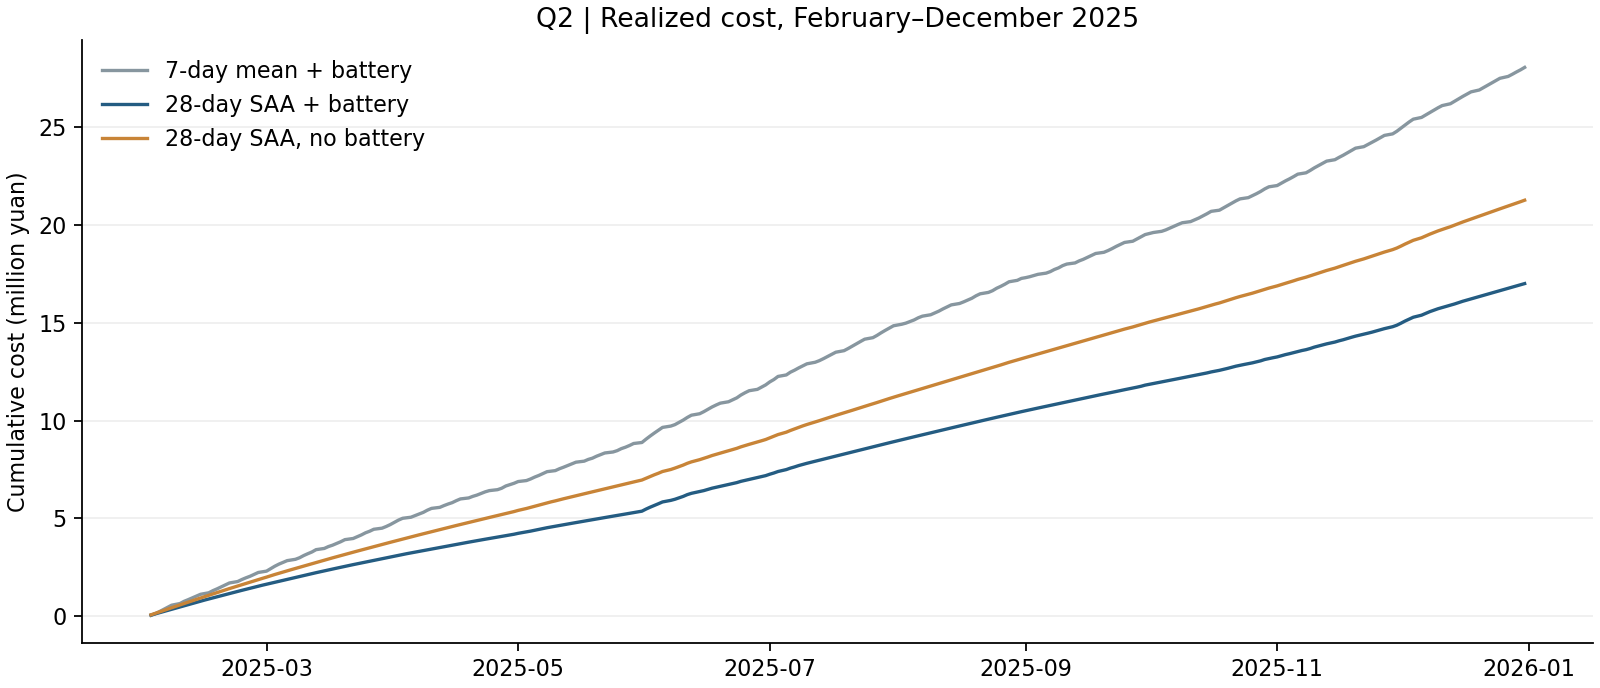

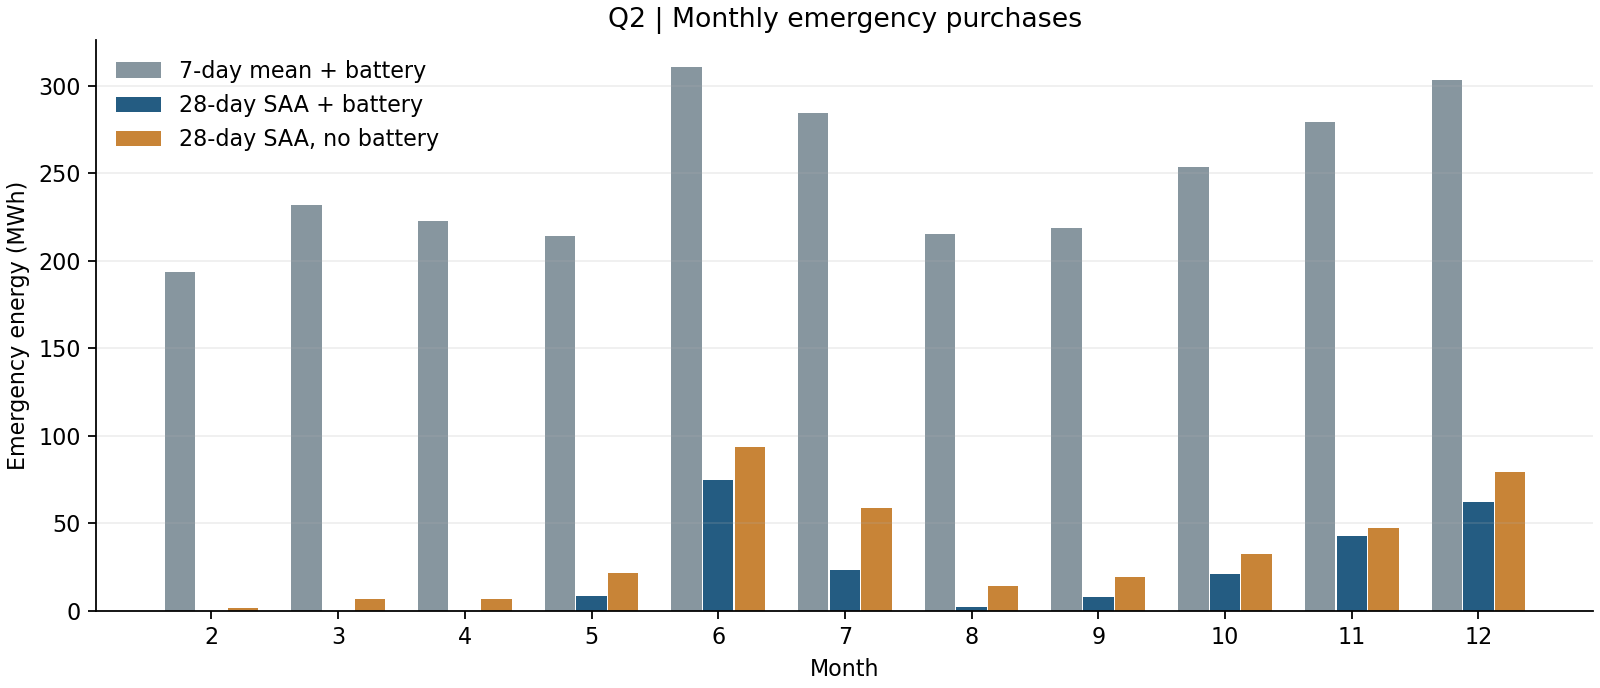

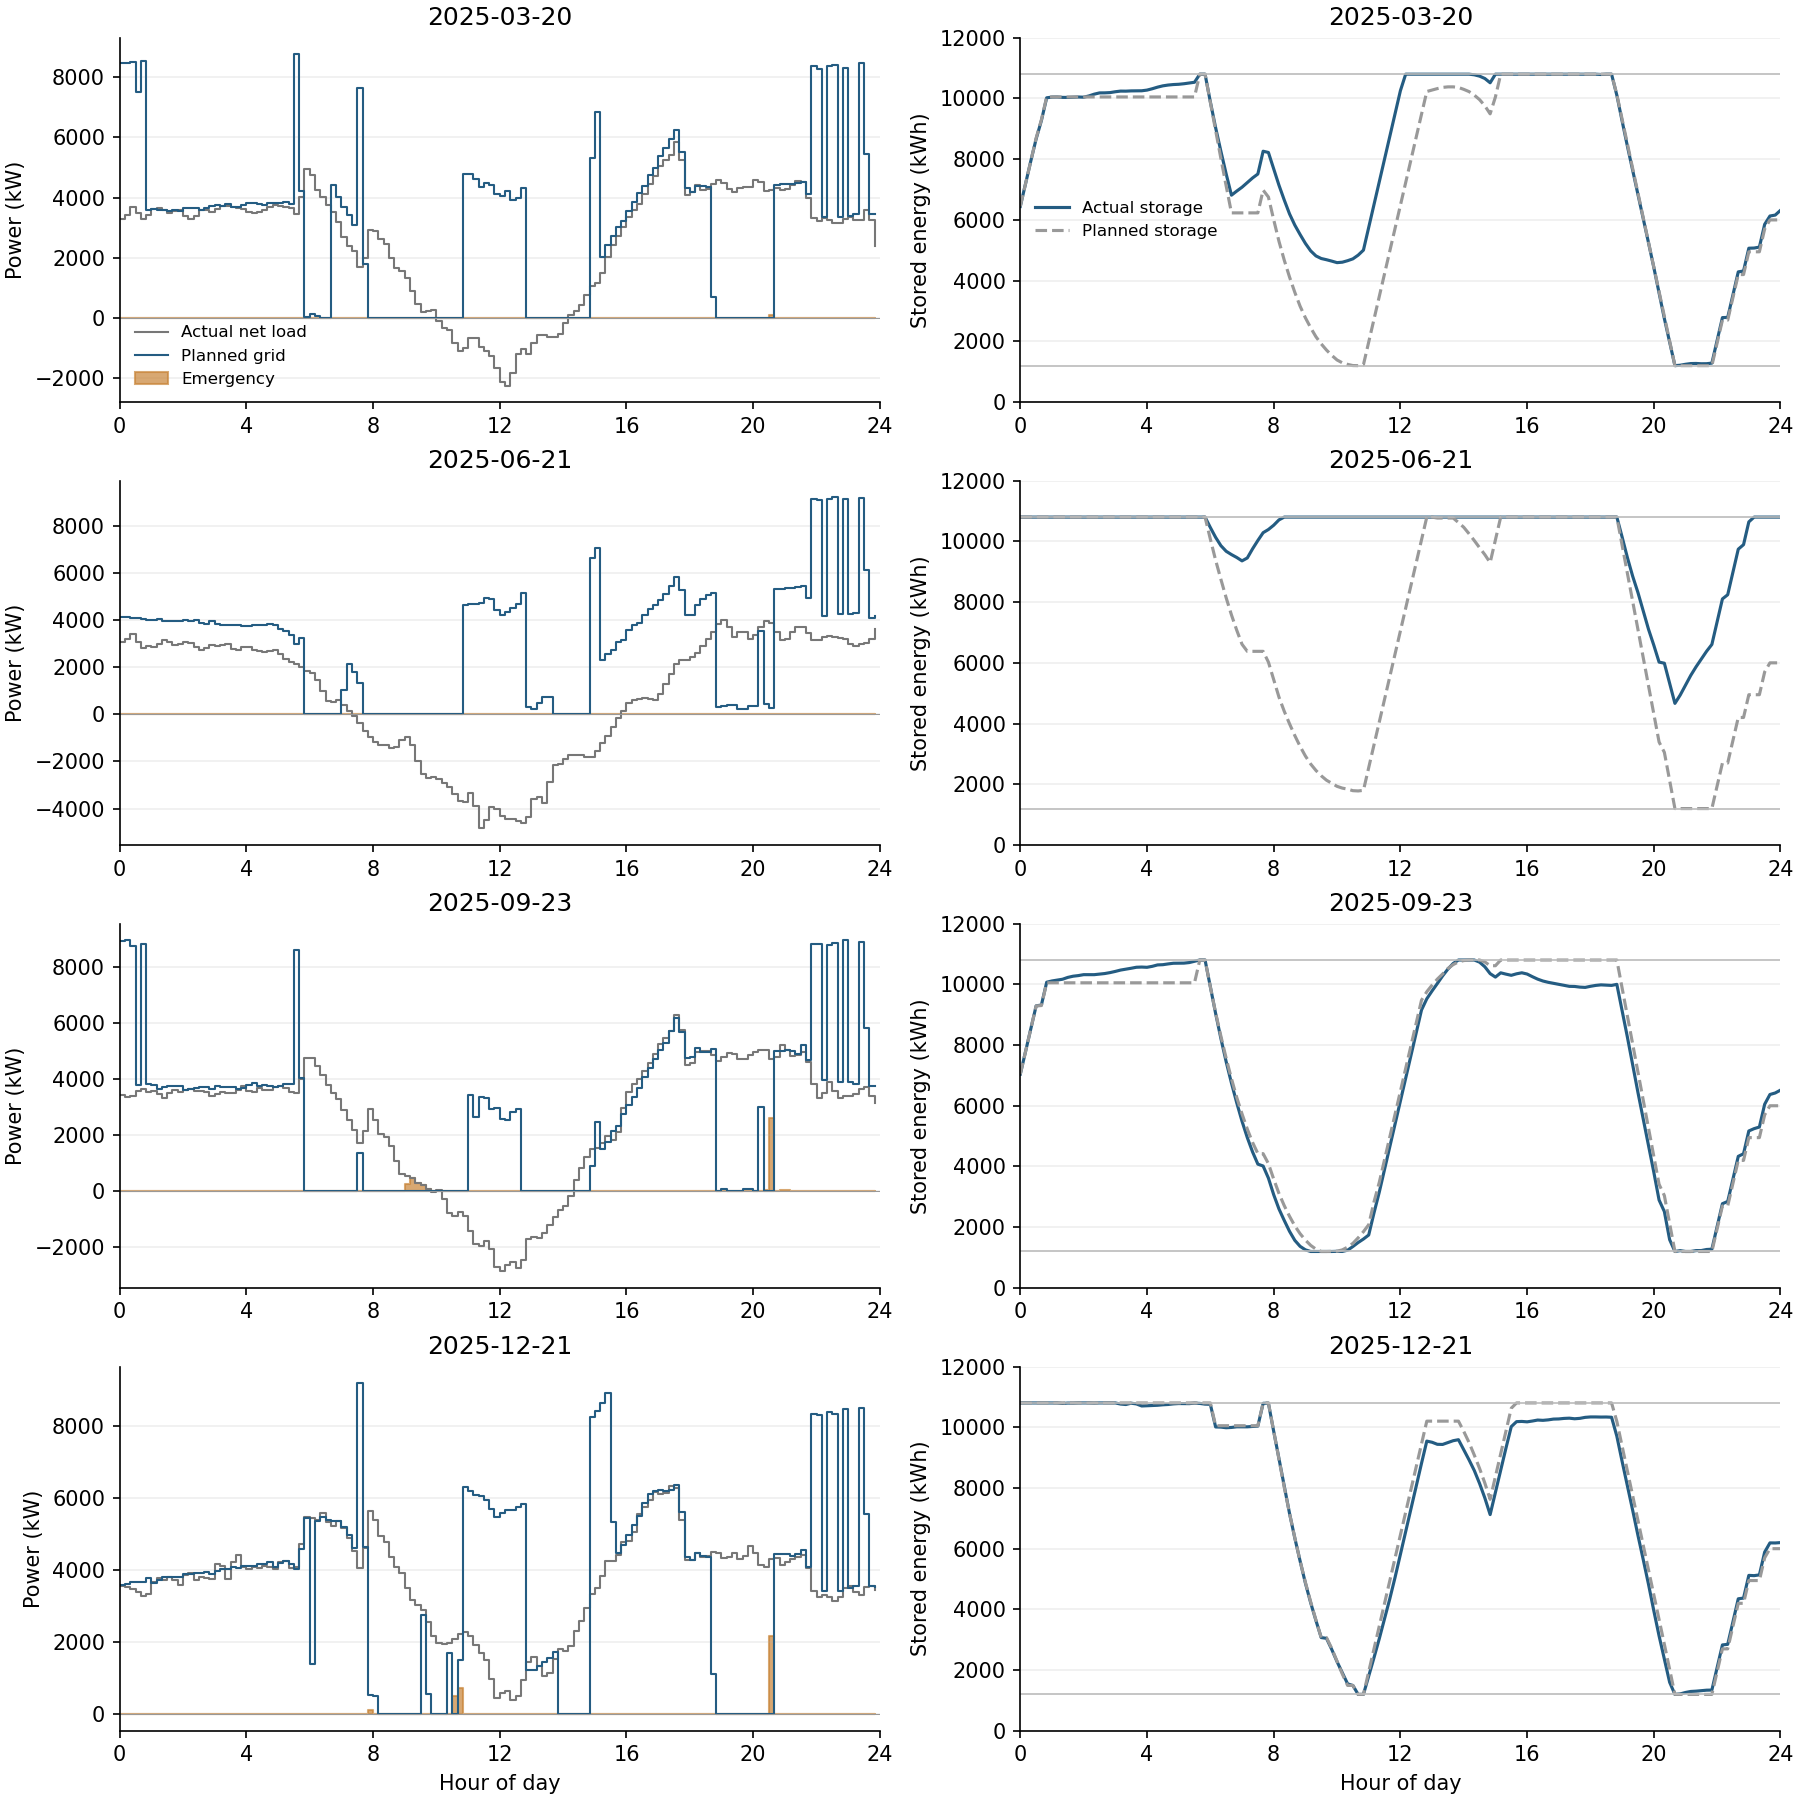

In [17]:
make_figures(results, OUT/'figures')
for filename in ['01_cumulative_cost.png','02_monthly_emergency.png','03_selected_days.png']:
    display(Image(filename=str(OUT/'figures'/filename)))


## 12. 导出

输出目录为当前工作目录下的 `q2_notebook_results`。包含 10 分钟明细、日前计划日志、日报、4 小时储能表、合并应急表、检查结果和 Excel 数据矩阵。

完整包中的 Excel 和 Markdown 报告对应已交付的默认参数计算。**修改参数重新运行后，CSV/JSON/PNG 会更新，原 Excel 和报告不会自动更新**。Excel 构建脚本 `export_workbook.mjs` 根据 JSON 矩阵导出，需具备其所列 Node 依赖的环境。

原模板首列为 `0:10-0:20`，内部计算首列为 `00:00-00:10`。本次 Excel 按明确物理区间列标题输出，并附说明；正式提交前须确认竞赛方时间口径。


In [18]:
def export_results(results,out,cfg=None):
    cfg=DEFAULT if cfg is None else cfg;out=Path(out);out.mkdir(parents=True,exist_ok=True)
    tables=make_tables(results[PRIMARY][0]);comparison=compare_strategies(results)
    comparison.to_csv(out/'strategy_comparison.csv',index=False,encoding='utf-8-sig')
    checks=[]
    for name,(x,diary) in results.items():
        q=verify_physics(x,cfg);q.insert(0,'strategy',name);checks.append(q)
        directory=out/name;directory.mkdir(exist_ok=True)
        x.to_csv(directory/'dispatch_10min_all_year.csv',index=False,encoding='utf-8-sig')
        diary.to_csv(directory/'planning_log.csv',index=False,encoding='utf-8-sig')
        daily_summary(x).to_csv(directory/'daily_summary_all_year.csv',index=False,encoding='utf-8-sig')
    pd.concat(checks,ignore_index=True).to_csv(out/'physical_checks.csv',index=False,encoding='utf-8-sig')
    for name,frame in tables.items():frame.to_csv(out/(name+'.csv'),index=False,encoding='utf-8-sig')
    payload={k:json.loads(v.to_json(orient='split',index=False)) for k,v in tables.items()}
    payload['comparison']=json.loads(comparison.to_json(orient='split',index=False))
    # Full precision matrices for spreadsheet output; DataFrame.to_json defaults to 10 decimal places.
    for name,frame in list(tables.items())+[('comparison',comparison)]:
        payload[name]={'columns':list(frame.columns),'data':frame.astype(object).where(pd.notna(frame),None).values.tolist()}
    (out/'workbook_data.json').write_text(json.dumps(payload,ensure_ascii=False,allow_nan=False),encoding='utf-8')
    summary=dict(primary_strategy=PRIMARY,parameters=cfg,
      evaluation_start='2025-02-01',evaluation_end='2025-12-31',evaluation_days=334,
      time_mapping='PROVISIONAL: endpoint observation interpreted as preceding ten-minute average',
      optimality='Historical-scenario planning surrogate only; greedy real-time control is heuristic.',
      checks_passed=bool(pd.concat(checks).passed.all()),comparison=comparison.to_dict('records'))
    (out/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
    return tables,comparison


In [19]:
tables, comparison = export_results(results, OUT, cfg)
physical.to_csv(OUT/'physical_checks.csv',index=False,encoding='utf-8-sig')
print('导出目录：', OUT)
print('2—12 月天数：', len(tables['daily_summary']))
print('4 小时储能记录数：', len(tables['storage_4h']))
print('合并应急事件数：', len(tables['emergency_events']))
print('模板时间映射：暂定，详见说明。')


导出目录： e:\桌面\CUMCM_2026\q2\q2_notebook_results
2—12 月天数： 334
4 小时储能记录数： 2004
合并应急事件数： 313
模板时间映射：暂定，详见说明。


## 13. 下一步改进方向

先结合 `Q2_Report.md` 把本版本的方法、假设和结果写入论文。若继续改进，可在仅使用当时可见数据的条件下做工作日/周末情景筛选、滚动窗口验证，以及考虑未来时段价值的储能控制。

当前方法仍会多买并浪费部分电量。28 日经验分布不能保证覆盖季节转折和极端天气；实时贪心控制也未优化跨时段储能价值。这些是后续改进点，不能用全年真实数据调好参数后再称为独立测试。
